In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, epsilon_0, pi

In [2]:
from utils.plot_style import set_plot_style
set_plot_style()

In [3]:
import nlo.targat as ta

# Numerical simulation

## Basic constants

Experimental values

In [4]:
l = 20e-3
wavelength = 780e-9
n1 = 1.8364
n2 = 1.9188
d_eff = 9.5e-12
epsilon = 0.02
P_in = 200e-3

In [5]:
omega1 = 2.0 * pi * c / wavelength
k1 = n1 * omega1 / c
prefactor = (2.0 * omega1**2 * (d_eff**2) * l * k1) / (pi * epsilon_0 * c**3 * (n1**2) * n2)

Absorption values

In [6]:
alpha1_cm = 0.001   # absorption coefficient for pump (1/cm)
alpha2_cm = 0.14    # absorption coefficient for harmonic (1/cm)

# Convert cm^-1 -> m^-1: 1 cm^-1 = 100 m^-1
alpha1_m = alpha1_cm * 100.0
alpha2_m = alpha2_cm * 100.0

alpha_phys = 0.5 * (alpha1_m + alpha2_m)
# Exponential pre-factor of absorption
pre = np.exp(-alpha_phys * l)

$\xi$ range to explore

In [7]:
# xi range to explore
xi_vals = np.linspace(0.1, 8.0, 300)  # avoid xi=0

# waists to mark (in micrometers) and convert to xi
waist_um = np.array([20.0, 30.0, 40.0, 50.0])
waist_m = waist_um * 1e-6
xi_markers = [ta.xi_from_waist(w0=w, l=l, wavelength=wavelength, n=n1) for w in waist_m]

## Loop to sweep

Loop over xi values; compute waist, z_R and dimensionless alpha for each xi

In [8]:
sigma_opts_noabs = []
h_maxs_noabs = []
sigma_opts_abs = []
h_maxs_abs = []
alpha_dim_list = []
w0_list = []

In [9]:
for xi in xi_vals:
    # compute beam waist corresponding to this xi: xi = l * lambda / (2 n pi w0^2)
    w0 = np.sqrt((l * wavelength) / (2.0 * n1 * np.pi * xi))
    w0_list.append(w0)
    # Rayleigh range (with refractive index n): z_R = pi * n * w0^2 / lambda
    z_R = np.pi * n1 * (w0 ** 2) / wavelength

    # dimensionless alpha used in integrand: use average physical alpha (in 1/m)
    alpha_dim = alpha_phys * z_R
    alpha_dim_list.append(alpha_dim)

    # compute optimal sigma and h_max for no absorption (alpha=0)
    sigma_noabs, h_noabs = ta.find_sigma_opt(xi, 0.0, sigma_bounds=(0.0, 5.0))
    sigma_opts_noabs.append(sigma_noabs)
    h_maxs_noabs.append(h_noabs)

    # compute optimal sigma and h_max for absorption case
    sigma_abs, h_abs = ta.find_sigma_opt(xi, alpha_dim, sigma_bounds=(0.0, 5.0))
    sigma_opts_abs.append(sigma_abs)
    h_maxs_abs.append(pre * h_abs)

Convert to numpy arrays

In [10]:
h_noabs = np.array(h_maxs_noabs)
h_abs = np.array(h_maxs_abs)

Find the $\Gamma$ 

In [11]:
# compute Gamma_eff arrays
Gamma0 = prefactor

Gamma_eff_noabs = Gamma0 * h_noabs # no absorption
Gamma_eff_abs = Gamma0 * h_abs

Gamma_total_abs = Gamma_eff_noabs * 1.1  # rough estimate of total with absorption from Le Targat

In [12]:
# compute optimal T1 arrays
T1_noabs = ta.optimal_T1(epsilon, Gamma_eff_noabs, P_in)
T1_abs = ta.optimal_T1(epsilon, Gamma_total_abs, P_in)

In [13]:
# compute circulating powers
Pcirc_noabs = ta.impedance_match_intravavity_power(P_in, T1_noabs)
Pcirc_abs = ta.impedance_match_intravavity_power(P_in, T1_abs)

In [14]:
# generated SH power and conversion efficiency
Psh_noabs = Gamma_eff_noabs * (Pcirc_noabs**2)
Psh_abs = Gamma_eff_abs * (Pcirc_abs**2)
# avoid divide by zero or nan
eta_noabs = np.where(np.isfinite(Psh_noabs), Psh_noabs / P_in, 0.0)
eta_abs = np.where(np.isfinite(Psh_abs), Psh_abs / P_in, 0.0)

Plot

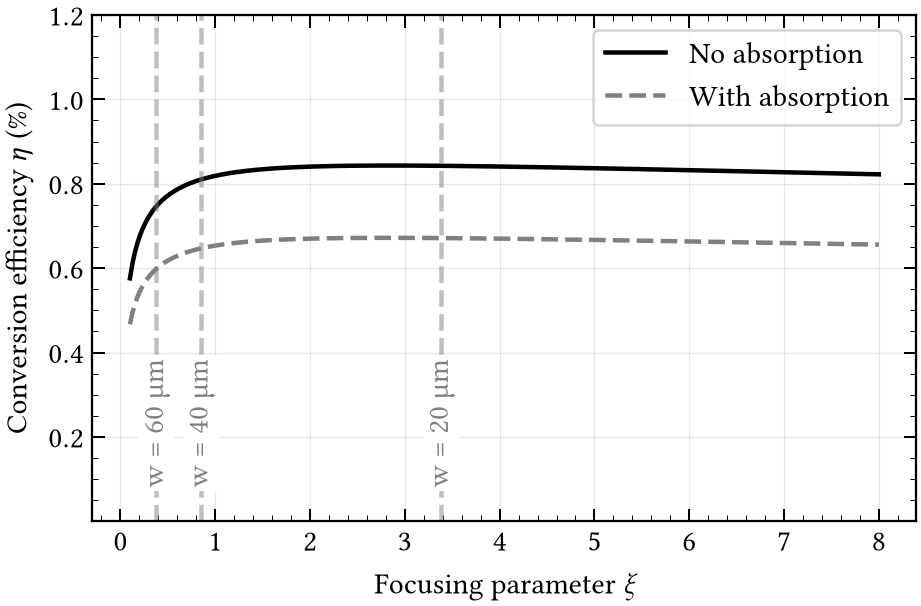

In [38]:
fig = plt.figure()

# define consistent colours
# color_noabs = plt.cm.tab10(0)  # blue-like
# color_abs = plt.cm.tab10(1)  # orange-like
color_noabs = "k"
color_abs = "grey"

plt.plot(xi_vals, eta_noabs, label='No absorption', color=color_noabs)
plt.plot(xi_vals, eta_abs, label='With absorption', color=color_abs, linestyle='--')
plt.xlabel(r'Focusing parameter $\xi$')
plt.ylabel(r'Conversion efficiency $\eta$ (\%)')

# --- annotate waists and corresponding values ---
waist_um = np.array([60.0, 40.0,  20.0])
xi_markers = [ta.xi_from_waist(w * 1e-6, l, wavelength, n1) for w in waist_um]

for w_um, xi_m in zip(waist_um, xi_markers):
    plt.axvline(x=xi_m, color='gray', linestyle='--', alpha=0.5)

    # Add waist label on top of the plot
    plt.text(
        xi_m,  # slightly left
        0.08,  # slightly above top
        f"w = {int(w_um)} µm",
        rotation=90,
        ha='center',
        va='bottom',
        color='gray',
        bbox=dict(facecolor='white', alpha=1.0, edgecolor='none', pad=1.5)
    )

    if xi_vals.min() <= xi_m <= xi_vals.max():
        # interpolate all quantities at this xi
        eta_noabs_at = np.interp(xi_m, xi_vals, eta_noabs)
        eta_abs_at = np.interp(xi_m, xi_vals, eta_abs)
        G_noabs_at = np.interp(xi_m, xi_vals, Gamma_eff_noabs)
        G_abs_at = np.interp(xi_m, xi_vals, Gamma_eff_abs)
        T1_noabs_at = np.interp(xi_m, xi_vals, T1_noabs)
        T1_abs_at = np.interp(xi_m, xi_vals, T1_abs)

        # positions around the curves
        y_noabs = eta_noabs_at * 1.2  # slightly above
        y_abs = eta_abs_at * 0.8  # slightly below

        # format text pairs
        txt_noabs = rf"$\eta = {eta_noabs_at:.3f}$" + "\n" + rf"$E_{{NL}} = {G_noabs_at:.2e}$" + "\n" + rf"$T_1={T1_noabs_at:.3f}$"
        txt_abs = rf"$\eta = {eta_abs_at:.3f}$" + "\n" + rf"$E_{{NL}} = {G_abs_at:.2e}$" + "\n" + rf"$T_1={T1_abs_at:.3f}$"

        # annotate above and below curves
        # plt.text(
        #     xi_m,
        #     y_noabs,
        #     txt_noabs,
        #     color=color_noabs,
        #     ha='center',
        #     va='bottom',
        #     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1.5)
        # )
        #
        # plt.text(
        #     xi_m,
        #     y_abs,
        #     txt_abs,
        #     color=color_abs,
        #     ha='center',
        #     va='top',
        #     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1.5)
        # )
ymin = 0.001
ymax = 1.
plt.ylim(ymin, max(ymax*1.2, 1.0))

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [39]:
fig.savefig('figure/' + 'eta_vs_xi_with_waists.svg', dpi=300)